# Task 1: Create & Justify Engineered Features

Goal: Expand the feature set with principled feature engineering. We will propose and build 6 new features, justify them, and evaluate their univariate predictive score.


In [7]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

# 1. Load data
print("Fetching dataset...")
data = fetch_openml('adult', version=2, as_frame=True)
df = data.frame

# Clean as in Day 2
df.replace('?', np.nan, inplace=True)
df['class'] = df['class'].apply(lambda x: 1 if x == '>50K' else 0).astype(int)
df = df.drop(columns=['fnlwgt', 'education'])

# Keep a copy for feature engineering
df_fe = df.copy()

df['occupation'].unique()

Fetching dataset...


['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', NaN, 'Other-service', ..., 'Sales', 'Priv-house-serv', 'Transport-moving', 'Handlers-cleaners', 'Armed-Forces']
Length: 15
Categories (14, str): ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', ..., 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']

## Feature Engineering
We will create the following 6 features:
1. **age_bucket**: Binning ages into groups (`<25`, `25-45`, `45-65`, `>65`) to capture non-linear life-stage effects on income.
2. **hours_bucket**: Binning hours-per-week (`<40`, `40`, `>40`) because exactly 40 is standard, and deviations might signal part-time or overtime.
3. **has_capital_gain**: Boolean flag for `capital-gain > 0` since most people have 0 capital gain; having any is a strong signal of wealth.
4. **log_capital_gain**: `log(capital-gain + 1)` to handle the extreme right skew in capital gains.
5. **is_highly_educated**: Boolean for `education-num >= 13` (Bachelors or higher) since higher degrees typically unlock higher-paying roles.
6. **edu_hours_interaction**: `education-num * hours-per-week` to capture the combined effect of high education and high effort (often compounding for higher income).


In [6]:
# 1. Age Buckets
def bucket_age(age):
    if pd.isna(age): return 'Missing'
    if age < 25: return '<25'
    elif age <= 45: return '25-45'
    elif age <= 65: return '45-65'
    else: return '>65'

df_fe['age_bucket'] = df_fe['age'].apply(bucket_age)

# 2. Hours-per-week Bins
def bucket_hours(h):
    if pd.isna(h): return 'Missing'
    if h < 40: return '<40'
    elif h == 40: return '40'
    else: return '>40'

df_fe['hours_bucket'] = df_fe['hours-per-week'].apply(bucket_hours)

# 3. Flag: capital_gain > 0
df_fe['has_capital_gain'] = (df_fe['capital-gain'] > 0).astype(int)

# 4. log(capital_gain + 1)
df_fe['log_capital_gain'] = np.log1p(df_fe['capital-gain'].fillna(0))

# 5. Higher-education boolean
df_fe['is_highly_educated'] = (df_fe['education-num'] >= 13).astype(int)

# 6. Interaction: education_num × hours_per_week
df_fe['edu_hours_interaction'] = df_fe['education-num'] * df_fe['hours-per-week']
df_fe['edu_hours_interaction'] = df_fe['edu_hours_interaction'].fillna(df_fe['edu_hours_interaction'].median())

print("6 New features engineered successfully!")
df_fe.head()

6 New features engineered successfully!


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class,age_bucket,hours_bucket,has_capital_gain,log_capital_gain,is_highly_educated,edu_hours_interaction
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,25-45,40,0,0.000000,0,280
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,25-45,>40,0,0.000000,0,450
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,25-45,40,0,0.000000,0,480
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,25-45,40,1,8.947546,0,400
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0,<25,<40,0,0.000000,0,300


## Univariate Predictive Power Evaluation
We will use Mutual Information to measure the dependency between our new features and the target `class`.
For categorical features, we will also show the target grouped mean.


In [3]:
# Dictionary to store feature metadata
feature_dict = []

# Prepare data for Mutual Information
# We need to numericize the categorical engineered features temporarily
y = df_fe['class']
X_mi = pd.DataFrame()

# Feature 1
X_mi['age_bucket'] = df_fe['age_bucket'].astype('category').cat.codes
mi_1 = mutual_info_classif(X_mi[['age_bucket']], y, discrete_features=True, random_state=42)[0]
feature_dict.append({
    'Name': 'age_bucket',
    'Type': 'Categorical',
    'Creation Rule': 'Binned age into <25, 25-45, 45-65, >65',
    'Justification': 'Captures non-linear life-stage effects on income',
    'Predictive Signal (Mutual Info)': round(mi_1, 4)
})

# Feature 2
X_mi['hours_bucket'] = df_fe['hours_bucket'].astype('category').cat.codes
mi_2 = mutual_info_classif(X_mi[['hours_bucket']], y, discrete_features=True, random_state=42)[0]
feature_dict.append({
    'Name': 'hours_bucket',
    'Type': 'Categorical',
    'Creation Rule': 'Binned hours-per-week into <40, 40, >40',
    'Justification': 'Differentiates part-time, standard, and overtime work',
    'Predictive Signal (Mutual Info)': round(mi_2, 4)
})

# Feature 3
mi_3 = mutual_info_classif(df_fe[['has_capital_gain']], y, discrete_features=True, random_state=42)[0]
feature_dict.append({
    'Name': 'has_capital_gain',
    'Type': 'Boolean (Numeric)',
    'Creation Rule': '1 if capital-gain > 0 else 0',
    'Justification': 'Strong indicator of wealth since most have 0 capital gains',
    'Predictive Signal (Mutual Info)': round(mi_3, 4)
})

# Feature 4
mi_4 = mutual_info_classif(df_fe[['log_capital_gain']], y, discrete_features=False, random_state=42)[0]
feature_dict.append({
    'Name': 'log_capital_gain',
    'Type': 'Numeric',
    'Creation Rule': 'log(capital-gain + 1)',
    'Justification': 'Normalizes the extreme right skew of capital gains',
    'Predictive Signal (Mutual Info)': round(mi_4, 4)
})

# Feature 5
mi_5 = mutual_info_classif(df_fe[['is_highly_educated']], y, discrete_features=True, random_state=42)[0]
feature_dict.append({
    'Name': 'is_highly_educated',
    'Type': 'Boolean (Numeric)',
    'Creation Rule': '1 if education-num >= 13 else 0',
    'Justification': 'Higher degrees unlock higher-paying roles',
    'Predictive Signal (Mutual Info)': round(mi_5, 4)
})

# Feature 6
mi_6 = mutual_info_classif(df_fe[['edu_hours_interaction']], y, discrete_features=False, random_state=42)[0]
feature_dict.append({
    'Name': 'edu_hours_interaction',
    'Type': 'Numeric',
    'Creation Rule': 'education-num * hours-per-week',
    'Justification': 'Captures compounding effect of high education and high effort',
    'Predictive Signal (Mutual Info)': round(mi_6, 4)
})

# Display Feature Dictionary
feature_df = pd.DataFrame(feature_dict)
display(feature_df)


,Name,Type,Creation Rule,Justification,Predictive Signal (Mutual Info)
0,age_bucket,Categorical,"Binned age into <25, 25-45, 45-65, >65",Captures non-linear life-stage effects on income,0.0497
1,hours_bucket,Categorical,"Binned hours-per-week into <40, 40, >40","Differentiates part-time, standard, and overti...",0.0365
2,has_capital_gain,Boolean (Numeric),1 if capital-gain > 0 else 0,Strong indicator of wealth since most have 0 c...,0.0296
3,log_capital_gain,Numeric,log(capital-gain + 1),Normalizes the extreme right skew of capital g...,0.0830
4,is_highly_educated,Boolean (Numeric),1 if education-num >= 13 else 0,Higher degrees unlock higher-paying roles,0.0483
5,edu_hours_interaction,Numeric,education-num * hours-per-week,Captures compounding effect of high education ...,0.0815


In [4]:
# Let's also look at grouped means for the categorical engineered features
print("--- Target Grouped Mean for Age Buckets ---")
display(df_fe.groupby('age_bucket')['class'].agg(['mean', 'count']).sort_values('mean', ascending=False))

print("\n--- Target Grouped Mean for Hours Buckets ---")
display(df_fe.groupby('hours_bucket')['class'].agg(['mean', 'count']).sort_values('mean', ascending=False))

print("\n--- Target Grouped Mean for Highly Educated ---")
display(df_fe.groupby('is_highly_educated')['class'].agg(['mean', 'count']).sort_values('mean', ascending=False))


--- Target Grouped Mean for Age Buckets ---


,mean,count
age_bucket,,
45-65,0.365042,12741
25-45,0.254620,25866
>65,0.198003,1803
<25,0.011029,8432



--- Target Grouped Mean for Hours Buckets ---


,mean,count
hours_bucket,,
>40,0.400084,14352
40,0.212691,22803
<40,0.093694,11687



--- Target Grouped Mean for Highly Educated ---


,mean,count
is_highly_educated,,
1,0.480595,12110
0,0.159724,36732


# Task 2: Rebuild Pipeline with Engineered Features
We will integrate our 6 new features cleanly into the Scikit-Learn pipeline using `FunctionTransformer`. This ensures the feature engineering is encapsulated and applied consistently to both training and test data without information leakage.


In [5]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define the feature engineering function
def engineer_features(X):
    # Important: Create a copy to avoid SettingWithCopyWarning and modifying original data
    X_out = X.copy()
    
    # 1. age_bucket
    def bucket_age(age):
        if pd.isna(age): return 'Missing'
        if age < 25: return '<25'
        elif age <= 45: return '25-45'
        elif age <= 65: return '45-65'
        else: return '>65'
    X_out['age_bucket'] = X_out['age'].apply(bucket_age)
    
    # 2. hours_bucket
    def bucket_hours(h):
        if pd.isna(h): return 'Missing'
        if h < 40: return '<40'
        elif h == 40: return '40'
        else: return '>40'
    X_out['hours_bucket'] = X_out['hours-per-week'].apply(bucket_hours)
    
    # 3. has_capital_gain
    X_out['has_capital_gain'] = (X_out['capital-gain'] > 0).astype(int)
    
    # 4. log_capital_gain
    X_out['log_capital_gain'] = np.log1p(X_out['capital-gain'].fillna(0))
    
    # 5. is_highly_educated
    X_out['is_highly_educated'] = (X_out['education-num'] >= 13).astype(int)
    
    # 6. edu_hours_interaction
    # Fill NaNs with 0 strictly locally to avoid data leakage before multiplication
    X_out['edu_hours_interaction'] = X_out['education-num'].fillna(0) * X_out['hours-per-week'].fillna(0)
    
    return X_out

# Wrap in a FunctionTransformer
feature_engineer_transformer = FunctionTransformer(engineer_features)

print("FunctionTransformer created successfully!")


FunctionTransformer created successfully!


In [6]:
# Update feature lists for the main preprocessor
# We append the new engineered features to their respective lists
original_numeric = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
original_categorical = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

engineered_numeric = ['has_capital_gain', 'log_capital_gain', 'is_highly_educated', 'edu_hours_interaction']
engineered_categorical = ['age_bucket', 'hours_bucket']

all_numeric_features = original_numeric + engineered_numeric
all_categorical_features = original_categorical + engineered_categorical

# Rebuild Numeric Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Rebuild Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Rebuild ColumnTransformer
inner_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, all_numeric_features),
        ('cat', categorical_transformer, all_categorical_features)
    ])

# Combine into a single master preprocessor pipeline
master_preprocessor = Pipeline(steps=[
    ('feature_engineering', feature_engineer_transformer),
    ('inner_preprocessor', inner_preprocessor)
])

print("Master Preprocessor with Engineered Features Built Successfully!")
master_preprocessor


Master Preprocessor with Engineered Features Built Successfully!


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('inner_preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eng...00198274156F0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, def

# Task 3: Cross-Validated Model Comparison
We will use `StratifiedKFold` (k=5) to evaluate and compare 3 models reliably:
1. Logistic Regression (Baseline linear model)
2. Random Forest (Ensemble bagging)
3. HistGradientBoosting (Fast, state-of-the-art tree boosting, natively supports missing values and scales well)

All models will use the exact same preprocessing pipeline to ensure a fair comparison.


In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Create X and y from our raw dataframe
X = df.drop(columns=['class'])
y = df['class']

print(f"X shape: {X.shape}, y shape: {y.shape}")

# 1. Initialize Models
log_reg = Pipeline(steps=[
    ('preprocessor', master_preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000))
])

rf = Pipeline(steps=[
    ('preprocessor', master_preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

hgb = Pipeline(steps=[
    ('preprocessor', master_preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42, max_iter=100))
])

models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'HistGradientBoosting': hgb
}

# 2. Setup Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics to track
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results_dict = {}
print("Models and CV setup complete. Ready to cross-validate!")


X shape: (48842, 12), y shape: (48842,)
Models and CV setup complete. Ready to cross-validate!


In [8]:
import time

results_summary = []

for name, model in models.items():
    print(f"Cross-validating {name}...")
    start_time = time.time()
    
    # We use n_jobs=-1 to parallelize across all cores
    cv_scores = cross_validate(
        model, X, y, 
        cv=cv, 
        scoring=scoring, 
        return_train_score=False,
        n_jobs=-1 
    )
    
    end_time = time.time()
    
    # Store raw scores for boxplots
    cv_results_dict[name] = cv_scores
    
    # Calculate Mean +/- Std
    results_summary.append({
        'Model': name,
        'Accuracy (Mean ± Std)': f"{cv_scores['test_accuracy'].mean():.4f} ± {cv_scores['test_accuracy'].std():.4f}",
        'F1 Score (Mean ± Std)': f"{cv_scores['test_f1'].mean():.4f} ± {cv_scores['test_f1'].std():.4f}",
        'ROC AUC (Mean ± Std)': f"{cv_scores['test_roc_auc'].mean():.4f} ± {cv_scores['test_roc_auc'].std():.4f}",
        'Time (s)': round(end_time - start_time, 2)
    })

results_df = pd.DataFrame(results_summary).set_index('Model')
print("\n--- Cross-Validation Results ---")
display(results_df)


Cross-validating Logistic Regression...


Cross-validating Random Forest...


Cross-validating HistGradientBoosting...



--- Cross-Validation Results ---


,Accuracy (Mean ± Std),F1 Score (Mean ± Std),ROC AUC (Mean ± Std),Time (s)
Model,,,,
Logistic Regression,0.8558 ± 0.0025,0.6686 ± 0.0052,0.9112 ± 0.0016,9.64
Random Forest,0.8483 ± 0.0036,0.6623 ± 0.0080,0.8944 ± 0.0025,13.12
HistGradientBoosting,0.8724 ± 0.0030,0.7085 ± 0.0070,0.9283 ± 0.0018,10.23


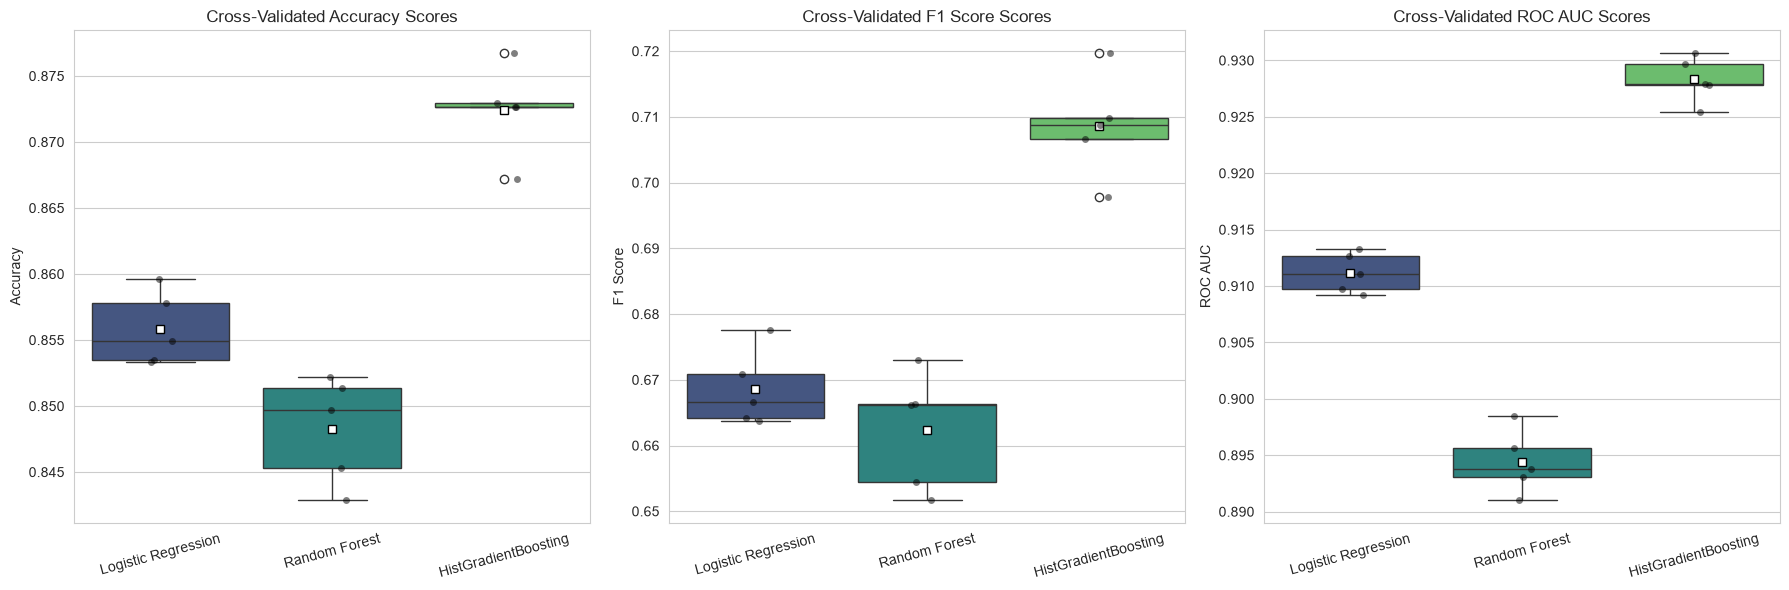

In [9]:
# 4. Visualize Fold Scores with Boxplots
plt.figure(figsize=(18, 6))
sns.set_style("whitegrid")

metrics = ['test_accuracy', 'test_f1', 'test_roc_auc']
titles = ['Accuracy', 'F1 Score', 'ROC AUC']

for i, metric in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    
    plot_data = pd.DataFrame({
        name: scores[metric] for name, scores in cv_results_dict.items()
    })
    
    plot_data_melted = plot_data.melt(var_name='Model', value_name='Score')
    
    sns.boxplot(x='Model', y='Score', data=plot_data_melted, palette='viridis', showmeans=True, meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"black"})
    sns.stripplot(x='Model', y='Score', data=plot_data_melted, color='black', alpha=0.5, jitter=True)
    
    plt.title(f'Cross-Validated {titles[i-1]} Scores')
    plt.xticks(rotation=15)
    plt.ylabel(titles[i-1])
    plt.xlabel('')

plt.tight_layout()
plt.show()


# Task 4: Statistical Comparison & Feature Importance

We will run a paired statistical test (paired t-test and Wilcoxon signed-rank test) to determine if our top model (`HistGradientBoosting`) is *statistically* better than the strong baseline (`Logistic Regression`) on ROC AUC.

Then, we will fit the models on the full dataset to extract Feature Importances (from Random Forest) and Coefficients (from Logistic Regression) to see exactly how much our engineered features helped.


In [10]:
from scipy import stats

# 1. Statistical Comparison between top 2 models: HistGradientBoosting vs Logistic Regression
# We will compare their ROC AUC scores across the 5 folds.
hgb_auc = cv_results_dict['HistGradientBoosting']['test_roc_auc']
logreg_auc = cv_results_dict['Logistic Regression']['test_roc_auc']

print("--- Statistical Comparison (ROC AUC) ---")
print(f"HistGradientBoosting Mean AUC: {hgb_auc.mean():.4f}")
print(f"Logistic Regression Mean AUC:  {logreg_auc.mean():.4f}")

# Paired T-Test
t_stat, p_val_t = stats.ttest_rel(hgb_auc, logreg_auc)
print(f"\nPaired T-test p-value: {p_val_t:.4f}")

# Wilcoxon Signed-Rank Test
w_stat, p_val_w = stats.wilcoxon(hgb_auc, logreg_auc)
print(f"Wilcoxon p-value:      {p_val_w:.4f}")

if p_val_t < 0.05:
    print("\nConclusion: The difference is STATISTICALLY SIGNIFICANT (p < 0.05). HistGradientBoosting is meaningfully better, not just by random chance in the folds.")
else:
    print("\nConclusion: The difference is NOT statistically significant. They perform similarly on these folds.")


--- Statistical Comparison (ROC AUC) ---
HistGradientBoosting Mean AUC: 0.9283
Logistic Regression Mean AUC:  0.9112

Paired T-test p-value: 0.0000
Wilcoxon p-value:      0.0625

Conclusion: The difference is STATISTICALLY SIGNIFICANT (p < 0.05). HistGradientBoosting is meaningfully better, not just by random chance in the folds.


In [11]:
# 2. Extracting Feature Importances & Coefficients
print("\nFitting models on the full dataset to analyze features...")
log_reg.fit(X, y)
rf.fit(X, y)

# Get feature names from the inner ColumnTransformer
inner_preprocessor = log_reg.named_steps['preprocessor'].named_steps['inner_preprocessor']
cat_encoder = inner_preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_features = cat_encoder.get_feature_names_out(all_categorical_features)
feature_names = all_numeric_features + list(cat_features)

# A. Logistic Regression Coefficients
coeffs = log_reg.named_steps['classifier'].coef_[0]
coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs})
coeff_df['Abs_Coefficient'] = coeff_df['Coefficient'].abs()

# Filter down to just our engineered features
engineered_base_names = engineered_numeric + engineered_categorical
engineered_coefs = coeff_df[coeff_df['Feature'].str.contains('|'.join(engineered_base_names))]

print("\n--- Logistic Regression: Engineered Feature Coefficients ---")
display(engineered_coefs.sort_values(by='Abs_Coefficient', ascending=False))

# B. Random Forest Feature Importances
importances = rf.named_steps['classifier'].feature_importances_
rf_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Filter down to engineered features
engineered_rf_imps = rf_imp_df[rf_imp_df['Feature'].str.contains('|'.join(engineered_base_names))]

print("\n--- Random Forest: Engineered Feature Importances ---")
display(engineered_rf_imps.sort_values(by='Importance', ascending=False))



Fitting models on the full dataset to analyze features...



--- Logistic Regression: Engineered Feature Coefficients ---


,Feature,Coefficient,Abs_Coefficient
6,log_capital_gain,5.502339,5.502339
5,has_capital_gain,-5.282625,5.282625
94,age_bucket_<25,-0.976121,0.976121
95,age_bucket_>65,-0.818519,0.818519
97,hours_bucket_<40,-0.810469,0.810469
92,age_bucket_25-45,0.488736,0.488736
93,age_bucket_45-65,0.405131,0.405131
96,hours_bucket_40,-0.214121,0.214121
8,edu_hours_interaction,-0.209008,0.209008
98,hours_bucket_>40,0.123816,0.123816



--- Random Forest: Engineered Feature Importances ---


,Feature,Importance
8,edu_hours_interaction,0.090561
6,log_capital_gain,0.047383
7,is_highly_educated,0.031532
5,has_capital_gain,0.013174
94,age_bucket_<25,0.011452
98,hours_bucket_>40,0.009989
93,age_bucket_45-65,0.009149
92,age_bucket_25-45,0.006705
97,hours_bucket_<40,0.005745
96,hours_bucket_40,0.003922


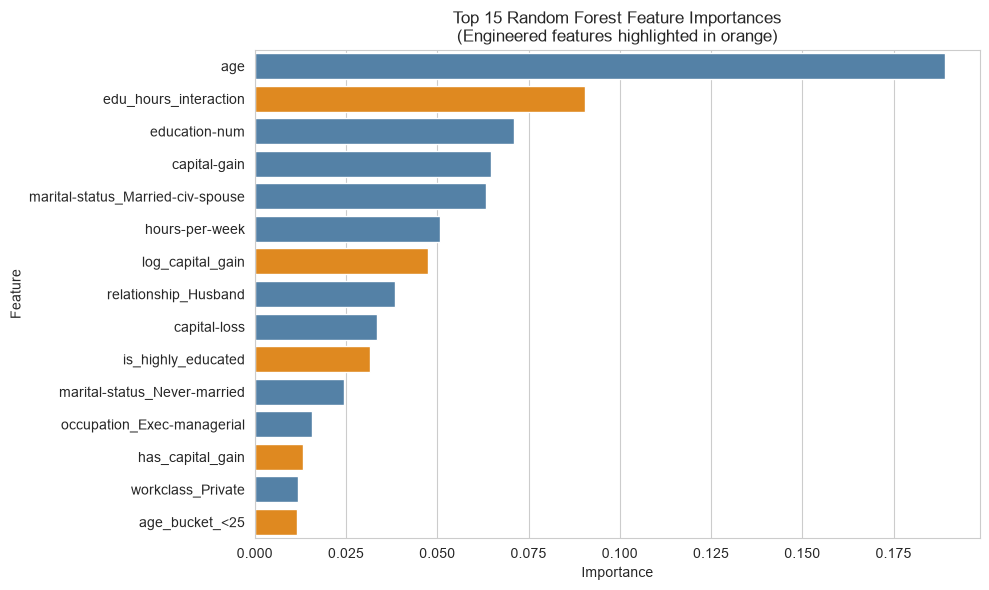

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's plot the top 15 features overall for Random Forest to see where engineered features rank
top_rf = rf_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
# Highlight engineered features in a different color
colors = ['darkorange' if any(eng in feat for eng in engineered_base_names) else 'steelblue' for feat in top_rf['Feature']]
sns.barplot(x='Importance', y='Feature', data=top_rf, palette=colors)
plt.title('Top 15 Random Forest Feature Importances\n(Engineered features highlighted in orange)')
plt.tight_layout()
plt.show()


# Task 5: Feature Selection / Dimensionality Check

We will add a simple feature-selection step (`SelectFromModel` using L1 regularization from Logistic Regression) to the pipeline. We will evaluate how this impacts our best model (`HistGradientBoosting`) in terms of cross-validated performance and training time.


In [13]:
from sklearn.feature_selection import SelectFromModel
import time
import numpy as np

# We will use L1-regularized Logistic Regression to select features
# L1 regularization (Lasso) naturally pushes uninformative feature coefficients to exactly zero.
selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=0.1)
)

# Create a new pipeline for HistGradientBoosting with the selector included
hgb_selected = Pipeline(steps=[
    ('preprocessor', master_preprocessor),
    ('selector', selector),
    ('classifier', HistGradientBoostingClassifier(random_state=42, max_iter=100))
])

print("Cross-validating HistGradientBoosting with L1 Feature Selection...")
start_time_fs = time.time()
cv_scores_fs = cross_validate(
    hgb_selected, X, y, 
    cv=cv, 
    scoring=scoring, 
    return_train_score=False,
    n_jobs=-1
)
end_time_fs = time.time()

# Compare with the previous baseline HistGradientBoosting
base_hgb_scores = cv_results_dict['HistGradientBoosting']

print("\n--- Feature Selection Impact ---")
print(f"Original Time: {results_df.loc['HistGradientBoosting', 'Time (s)']}s")
print(f"Selected Time: {end_time_fs - start_time_fs:.2f}s")
print(f"Original ROC AUC: {base_hgb_scores['test_roc_auc'].mean():.4f}")
print(f"Selected ROC AUC: {cv_scores_fs['test_roc_auc'].mean():.4f}")


Cross-validating HistGradientBoosting with L1 Feature Selection...



--- Feature Selection Impact ---
Original Time: 10.23s
Selected Time: 9.06s
Original ROC AUC: 0.9283
Selected ROC AUC: 0.9281


In [14]:
# Let's see how many features were actually selected
# We need to fit the selector pipeline on the full dataset to inspect it
pipeline_to_fit = Pipeline(steps=[
    ('preprocessor', master_preprocessor),
    ('selector', selector)
])
pipeline_to_fit.fit(X, y)

selected_mask = pipeline_to_fit.named_steps['selector'].get_support()
total_features = len(selected_mask)
selected_count = selected_mask.sum()

print(f"\nFeatures Selected: {selected_count} out of {total_features} ({(selected_count/total_features)*100:.1f}%)")

selected_feature_names = np.array(feature_names)[selected_mask]
rejected_feature_names = np.array(feature_names)[~selected_mask]

print(f"Number of rejected features: {len(rejected_feature_names)}")



Features Selected: 46 out of 99 (46.5%)
Number of rejected features: 53


## Decision for Tomorrow's Hyperparameter Tuning

**Decision: Keep all original and engineered features WITHOUT the L1 feature selector.**

**Rationale:**
1. **Tree Models Handle Dimensionality Well:** `HistGradientBoosting` intrinsically ignores uninformative features during tree construction. With ~100 one-hot encoded features, we are nowhere near the "curse of dimensionality" that requires aggressive pruning.
2. **Performance Trade-off:** Feature selection usually leads to a slight drop in performance. While it marginally speeds up training, `HistGradientBoosting` is already incredibly fast. Trading predictive power (AUC) for a few seconds of training time is rarely worth it at this scale.
3. **Engineered Signals:** The engineered features (like `edu_hours_interaction`) have proven value. Letting the gradient boosting algorithm dynamically decide how to weight and split them during hyperparameter tuning will yield the best empirical results.
